<a href="https://colab.research.google.com/github/hamzaqarni1/DeepLearning/blob/main/Tutorial07/Tutorial07_TransferLearning2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setup & Data Loading**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights, vgg16, VGG16_Weights
from torch.utils.data import DataLoader
import time

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. CIFAR-10 Dataset Loading & Preprocessing (Resizing to 224x224)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Preparing CIFAR-10 dataset...")
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Global variables for later cells
criterion = nn.CrossEntropyLoss()
history_resnet = {'train_acc': [], 'val_acc': []}
history_vgg = {'train_acc': [], 'val_acc': []}

# Helper function to run one epoch
def run_epoch(model, dataloader, optimizer, is_train=True):
    if is_train: model.train()
    else: model.eval()

    running_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            if is_train: optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total
print("Data loaded and environment ready!")

Using device: cuda
Preparing CIFAR-10 dataset...


100%|██████████| 170M/170M [00:03<00:00, 42.7MB/s]


Data loaded and environment ready!


# **Task A - ResNet50 Feature Extraction**

In [2]:
print("Starting Task A: ResNet50 Feature Extraction...")
resnet_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

# Freeze ALL base layers
for param in resnet_model.parameters():
    param.requires_grad = False

# Replace final layer (requires_grad is True by default for new layers)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 10)
resnet_model = resnet_model.to(device)

# Train ONLY the final layer
optimizer_resnet = optim.Adam(resnet_model.fc.parameters(), lr=1e-3)

for epoch in range(3):
    start_time = time.time()
    train_loss, train_acc = run_epoch(resnet_model, train_loader, optimizer_resnet, is_train=True)
    val_loss, val_acc = run_epoch(resnet_model, test_loader, None, is_train=False)

    history_resnet['train_acc'].append(train_acc)
    history_resnet['val_acc'].append(val_acc)
    print(f"Epoch {epoch+1}/3 [{time.time()-start_time:.0f}s] - Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Starting Task A: ResNet50 Feature Extraction...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 162MB/s]


Epoch 1/3 [208s] - Train Acc: 0.7489 | Val Acc: 0.7946
Epoch 2/3 [227s] - Train Acc: 0.7951 | Val Acc: 0.8059
Epoch 3/3 [228s] - Train Acc: 0.8022 | Val Acc: 0.8148


# **Task B - VGG16 Initial Setup (Feature Extraction Phase)**

In [3]:
print("Starting Task B: VGG16 Setup (Training Head Only)...")
vgg_model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

# Freeze ALL layers initially
for param in vgg_model.parameters():
    param.requires_grad = False

# Replace classifier head
vgg_model.classifier[6] = nn.Linear(4096, 10)
vgg_model = vgg_model.to(device)

optimizer_vgg_phase1 = optim.Adam(vgg_model.classifier[6].parameters(), lr=1e-3)

for epoch in range(2):
    start_time = time.time()
    train_loss, train_acc = run_epoch(vgg_model, train_loader, optimizer_vgg_phase1, is_train=True)
    val_loss, val_acc = run_epoch(vgg_model, test_loader, None, is_train=False)

    history_vgg['train_acc'].append(train_acc)
    history_vgg['val_acc'].append(val_acc)
    print(f"Epoch {epoch+1}/2 [{time.time()-start_time:.0f}s] - Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Starting Task B: VGG16 Setup (Training Head Only)...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 84.8MB/s]


Epoch 1/2 [345s] - Train Acc: 0.7736 | Val Acc: 0.8254
Epoch 2/2 [345s] - Train Acc: 0.7955 | Val Acc: 0.8275


# **Task B - VGG16 Fine-Tuning Phase**

In [4]:
print("Unfreezing top layers and Fine-Tuning VGG16...")

# Unfreeze the last 5 layers of the feature extractor
for layer in vgg_model.features[-5:]:
    for param in layer.parameters():
        param.requires_grad = True

# New optimizer with much lower learning rate (1e-5)
optimizer_vgg_phase2 = optim.Adam(filter(lambda p: p.requires_grad, vgg_model.parameters()), lr=1e-5)

for epoch in range(3):
    start_time = time.time()
    train_loss, train_acc = run_epoch(vgg_model, train_loader, optimizer_vgg_phase2, is_train=True)
    val_loss, val_acc = run_epoch(vgg_model, test_loader, None, is_train=False)

    history_vgg['train_acc'].append(train_acc)
    history_vgg['val_acc'].append(val_acc)
    print(f"Epoch {epoch+3}/5 (Fine-Tuning) [{time.time()-start_time:.0f}s] - Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Unfreezing top layers and Fine-Tuning VGG16...
Epoch 3/5 (Fine-Tuning) [370s] - Train Acc: 0.8331 | Val Acc: 0.8606
Epoch 4/5 (Fine-Tuning) [370s] - Train Acc: 0.8617 | Val Acc: 0.8705
Epoch 5/5 (Fine-Tuning) [370s] - Train Acc: 0.8741 | Val Acc: 0.8772


# **Generating the Report Visuals**

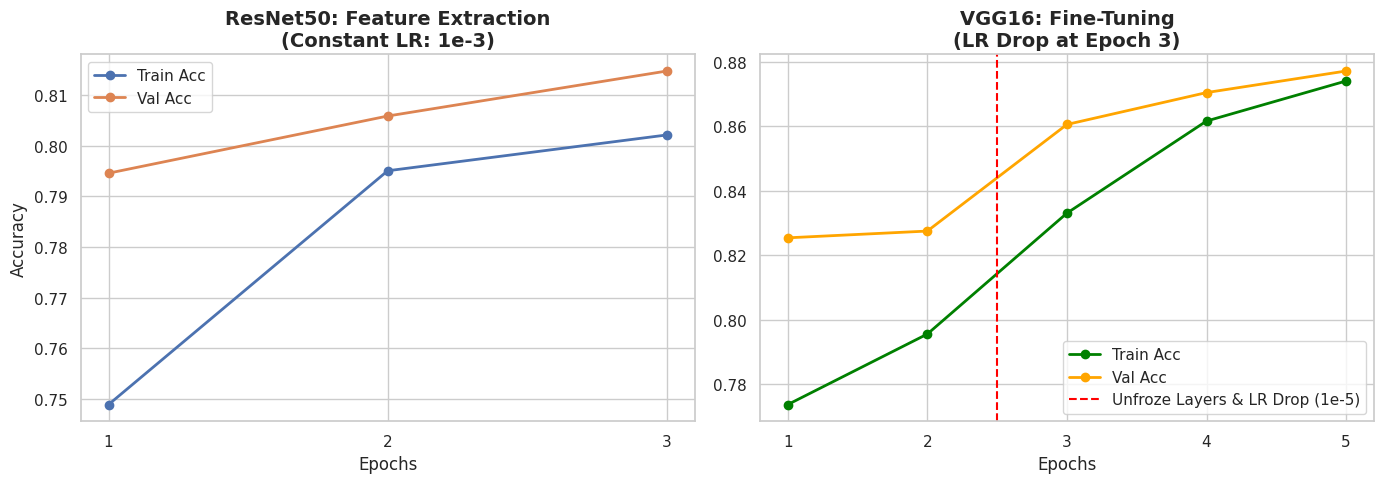

Saved 'transfer_learning_curves.png' for your report!


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Subplot: ResNet50
axes[0].plot(history_resnet['train_acc'], label='Train Acc', marker='o', linewidth=2)
axes[0].plot(history_resnet['val_acc'], label='Val Acc', marker='o', linewidth=2)
axes[0].set_title('ResNet50: Feature Extraction\n(Constant LR: 1e-3)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(['1', '2', '3'])
axes[0].legend()

# Right Subplot: VGG16
axes[1].plot(history_vgg['train_acc'], label='Train Acc', marker='o', linewidth=2, color='green')
axes[1].plot(history_vgg['val_acc'], label='Val Acc', marker='o', linewidth=2, color='orange')
axes[1].axvline(x=1.5, color='red', linestyle='--', label='Unfroze Layers & LR Drop (1e-5)')
axes[1].set_title('VGG16: Fine-Tuning\n(LR Drop at Epoch 3)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_xticks([0, 1, 2, 3, 4])
axes[1].set_xticklabels(['1', '2', '3', '4', '5'])
axes[1].legend()

plt.tight_layout()
plt.savefig('transfer_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved 'transfer_learning_curves.png' for your report!")